## Exercise 4: Teks Pre-Processing

1. Kezia Afiya Aulia (25031554031)
2. Filza Arifatuzzahra (25031554114)

## Bagian 1: Data Acquisition / Web Scraping X (Twitter)
Scraping minimal 520 tweet unik tentang Prabowo Subianto menggunakan **X GraphQL API + Session Cookies**.

### Setup: Ambil Cookies dari Browser
1. Buka [x.com](https://x.com) dan **login** di browser
2. Tekan `F12` → tab **Application** → **Cookies** → `https://x.com`
3. Salin nilai dari:
   - `auth_token` (string ~40 karakter)
   - `ct0` (token CSRF)
4. Paste ke file **`.env`** di folder project:
   ```
   TWITTER_AUTH_TOKEN=paste_auth_token_disini
   TWITTER_CT0=paste_ct0_disini
   ```
5. Restart kernel lalu Run All

In [ ]:
!apt-get update
!wget https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!dpkg -i google-chrome-stable_current_amd64.deb
!apt-get install -f -y

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ InRelease [3,631 B]
Get:3 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Hit:5 http://archive.ubuntu.com/ubuntu noble InRelease
Get:6 https://r2u.stat.illinois.edu/ubuntu noble InRelease [9,161 B]
Get:7 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ Packages [73.2 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu noble/main amd64 Packages [3,040 kB]
Get:10 http://security.ubuntu.com/ubuntu noble-security/universe amd64 Packages [1,543 kB]
Get:11 http://archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu noble/main all Packages [10.3 MB]
Get:13 http://archive.ubuntu.com/ubuntu noble-updates/restricted amd64 Packages [2,127 kB]
Get:14 h

In [ ]:
# === Install & Import Dependencies ===
!pip install demoji
!pip install selenium python-dotenv
import warnings
warnings.filterwarnings('ignore')

import re
import string
import pandas as pd
import numpy as np
import demoji
import nltk
from collections import Counter

# Download NLTK data
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('universal_tagset', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

print('All imports OK.')

All imports OK.


In [ ]:
# === Bagian 1: Data Acquisition / Web Scraping X (Twitter) ===
# Metode: Selenium Headless Chrome + DevTools Network Interceptor (CDP)
# Menggunakan session cookies dari browser (.env) untuk mengakses data asli X secara aman dan stabil.

import os
import time
import json
import urllib.parse
from dotenv import load_dotenv
import pandas as pd
from selenium import webdriver
from selenium.webdriver.chrome.options import Options

load_dotenv()
AUTH_TOKEN = os.getenv('TWITTER_AUTH_TOKEN')
CT0 = os.getenv('TWITTER_CT0')

assert AUTH_TOKEN and AUTH_TOKEN != 'salin_nilai_auth_token_disini', \
    'Isi TWITTER_AUTH_TOKEN di file .env terlebih dahulu!'
assert CT0 and CT0 != 'salin_nilai_ct0_disini', \
    'Isi TWITTER_CT0 di file .env terlebih dahulu!'

RAW_CSV_PATH = 'scrapingx.csv'

def scrape_x_tweets(target_count=520, use_existing_if_available=True):
    """
    Melakukan scraping tweet secara otomatis menggunakan Selenium headless browser.
    Mengambil data JSON SearchTimeline dari Chrome DevTools Protocol (CDP) secara realtime.
    """
    if use_existing_if_available and os.path.exists(RAW_CSV_PATH):
        try:
            cached_df = pd.read_csv(RAW_CSV_PATH)
            if len(cached_df) >= 500:
                print(f"[CACHE] Ditemukan file '{RAW_CSV_PATH}' dengan {len(cached_df)} tweet.")
                print("Memuat dataset yang sudah berhasil di-scrape sebelumnya...")
                return cached_df.to_dict('records')
        except Exception as e:
            print(f"Gagal membaca cache CSV: {e}, memulai scraping ulang...")

    print("Menginisialisasi Chrome Headless Browser...")
    options = Options()
    options.add_argument('--headless=new')
    options.add_argument('--disable-gpu')
    options.add_argument('--no-sandbox')
    options.add_argument('--disable-dev-shm-usage')  # Menghindari crash memori shared
    options.add_argument('--window-size=1920,1080')
    options.add_argument('user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/130.0.0.0 Safari/537.36')
    options.set_capability('goog:loggingPrefs', {'performance': 'ALL'})

    driver = webdriver.Chrome(options=options)
    all_tweets = []
    seen_ids = set()

    queries = [
        '"prabowo"',
        '"wowo"',
        '"prbw"',
        '"gemoy"',
    ]

    try:
        # Injeksi session cookies
        driver.get('https://x.com')
        time.sleep(3)
        driver.add_cookie({'name': 'auth_token', 'value': AUTH_TOKEN, 'domain': '.x.com', 'path': '/'})
        driver.add_cookie({'name': 'ct0', 'value': CT0, 'domain': '.x.com', 'path': '/'})

        processed_reqs = set()

        for q in queries:
            if len(all_tweets) >= target_count:
                break
            print(f'\nScraping query: {q} ...')
            encoded_q = urllib.parse.quote(q)
            driver.get(f'https://x.com/search?q={encoded_q}&f=live')
            time.sleep(5)

            consecutive_no_new = 0

            for scroll in range(35):
                if len(all_tweets) >= target_count:
                    break

                logs = driver.get_log('performance')
                new_this_scroll = 0
                for entry in logs:
                    try:
                        msg = json.loads(entry['message'])['message']
                        if msg.get('method') == 'Network.responseReceived':
                            resp = msg.get('params', {}).get('response', {})
                            if 'SearchTimeline' in resp.get('url', ''):
                                req_id = msg.get('params', {}).get('requestId')
                                if req_id not in processed_reqs:
                                    processed_reqs.add(req_id)
                                    body_obj = driver.execute_cdp_cmd('Network.getResponseBody', {'requestId': req_id})
                                    data = json.loads(body_obj['body'])
                                    instructions = data['data']['search_by_raw_query']['search_timeline']['timeline']['instructions']
                                    for inst in instructions:
                                        for e in inst.get('entries', []):
                                            if e.get('entryId', '').startswith('tweet-'):
                                                res = e.get('content', {}).get('itemContent', {}).get('tweet_results', {}).get('result', {})
                                                if res.get('__typename') == 'TweetWithVisibilityResults':
                                                    res = res.get('tweet', {})
                                                legacy = res.get('legacy', {})
                                                full_text = legacy.get('full_text', '')

                                                # Filter duplikasi & retweet murni
                                                if not full_text or full_text.startswith('RT @') or legacy.get('retweeted_status_result'):
                                                    continue
                                                tid = str(legacy.get('id_str', ''))
                                                if tid and tid not in seen_ids:
                                                    seen_ids.add(tid)
                                                    user_res = res.get('core', {}).get('user_results', {}).get('result', {})
                                                    username = (user_res.get('legacy', {}).get('screen_name') or
                                                                user_res.get('core', {}).get('screen_name') or '')
                                                    created_at = legacy.get('created_at', '')
                                                    likes = legacy.get('favorite_count', 0)
                                                    rts = legacy.get('retweet_count', 0)
                                                    metrics = f"likes: {likes}, retweets: {rts}"
                                                    all_tweets.append({
                                                        'id': tid,
                                                        'created_at': created_at,
                                                        'username': username,
                                                        'tweet_text': full_text,
                                                        'metrics': metrics
                                                    })
                                                    new_this_scroll += 1
                    except Exception:
                        pass

                print(f"  Scroll {scroll+1}: +{new_this_scroll} tweet baru (Total terkumpul: {len(all_tweets)})")

                if new_this_scroll == 0:
                    consecutive_no_new += 1
                    if consecutive_no_new >= 4:
                        break
                else:
                    consecutive_no_new = 0

                driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
                time.sleep(2.5)

    finally:
        driver.quit()

    print(f"\nSelesai! Berhasil mengumpulkan {len(all_tweets)} tweet unik.")
    return all_tweets

# Jalankan Fungsi Scraping
all_tweets = scrape_x_tweets(target_count=520, use_existing_if_available=True)
print(f"Total tweet tersedia dalam memori: {len(all_tweets)}")

Gagal membaca cache CSV: No columns to parse from file, memulai scraping ulang...
Menginisialisasi Chrome Headless Browser...

Scraping query: "prabowo" ...
  Scroll 1: +20 tweet baru (Total terkumpul: 20)
  Scroll 2: +20 tweet baru (Total terkumpul: 40)
  Scroll 3: +20 tweet baru (Total terkumpul: 60)
  Scroll 4: +40 tweet baru (Total terkumpul: 100)
  Scroll 5: +20 tweet baru (Total terkumpul: 120)
  Scroll 6: +60 tweet baru (Total terkumpul: 180)
  Scroll 7: +40 tweet baru (Total terkumpul: 220)
  Scroll 8: +20 tweet baru (Total terkumpul: 240)
  Scroll 9: +20 tweet baru (Total terkumpul: 260)
  Scroll 10: +40 tweet baru (Total terkumpul: 300)
  Scroll 11: +20 tweet baru (Total terkumpul: 320)
  Scroll 12: +20 tweet baru (Total terkumpul: 340)
  Scroll 13: +20 tweet baru (Total terkumpul: 360)
  Scroll 14: +40 tweet baru (Total terkumpul: 400)
  Scroll 15: +20 tweet baru (Total terkumpul: 420)
  Scroll 16: +40 tweet baru (Total terkumpul: 460)
  Scroll 17: +20 tweet baru (Total terk

In [ ]:
%%shell
# Pasang Chromium, ChromeDriver, dan dependencies sistem yang diperlukan
sudo apt-get update
sudo apt-get install -y chromium-chromedriver chromium-browser

Get:1 https://dl.google.com/linux/chrome-stable/deb stable InRelease [2,548 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ InRelease
Get:4 https://dl.google.com/linux/chrome-stable/deb stable/main amd64 Packages [1,411 B]
Hit:5 http://archive.ubuntu.com/ubuntu noble InRelease
Hit:6 http://security.ubuntu.com/ubuntu noble-security InRelease
Get:7 https://r2u.stat.illinois.edu/ubuntu noble InRelease [9,161 B]
Hit:8 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:9 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Hit:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu noble InRelease
Get:11 https://r2u.stat.illinois.edu/ubuntu noble/main all Packages [10.3 MB]
Get:12 https://r2u.stat.illinois.edu/ubuntu noble/main amd64 Packages [3,040 kB]
Fetched 13.3 MB in 2s (7,322 kB/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repositor

In [ ]:
# Modifikasi inisialisasi webdriver pada fungsi scraping agar menggunakan binary chromium-chromedriver yang baru dipasang
import os
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options

# Mengatur path binary Chrome dan ChromeDriver yang sesuai dengan instalasi apt
def get_colab_patched_webdriver():
    options = Options()
    options.add_argument('--headless=new')
    options.add_argument('--no-sandbox')
    options.add_argument('--disable-dev-shm-usage')
    options.add_argument('--disable-gpu')
    options.add_argument('--window-size=1920,1080')
    options.add_argument('user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/130.0.0.0 Safari/537.36')
    options.set_capability('goog:loggingPrefs', {'performance': 'ALL'})

    # Menentukan lokasi binary chromium jika terpasang lewat apt
    options.binary_location = "/usr/bin/chromium-browser"
    service = Service(executable_path="/usr/bin/chromedriver")

    driver = webdriver.Chrome(service=service, options=options)
    return driver

print("Konfigurasi Driver Baru Berhasil Dibuat. Silakan gunakan fungsi ini di bagian inisialisasi driver Anda.")

Konfigurasi Driver Baru Berhasil Dibuat. Silakan gunakan fungsi ini di bagian inisialisasi driver Anda.


In [ ]:
# Build DataFrame & save raw CSV
import pandas as pd
from google.colab import files

df_raw = pd.DataFrame(all_tweets, columns=['id', 'created_at', 'username', 'tweet_text', 'metrics'])
df_raw.drop_duplicates(subset='id', inplace=True)
df_raw.reset_index(drop=True, inplace=True)

# Normalisasi newline agar 1 tweet = 1 baris CSV yang rapi
df_raw['tweet_text'] = df_raw['tweet_text'].astype(str).str.replace(r'[\r\n]+', ' ', regex=True).str.strip()

RAW_CSV = 'scrapinx.csv'
df_raw.to_csv(RAW_CSV, index=False)
print(f'Saved {len(df_raw)} tweets to {RAW_CSV}')
files.download(RAW_CSV)
df_raw.head(10)

Saved 520 tweets to scrapinx.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,id,created_at,username,tweet_text,metrics
0,2106352505982681411,Sat Oct 03 11:55:46 +0000 2026,andirarahman,@alexanderdrspan @indischetroopen Ya berarti k...,"likes: 0, retweets: 0"
1,2106352415197004269,Sat Oct 03 11:55:24 +0000 2026,billcipher701,"@VeilByEclipse Sebagai sekre, cegat minta cepe...","likes: 0, retweets: 0"
2,2106352402219860462,Sat Oct 03 11:55:21 +0000 2026,__anomali__,PEMBOROSAN Perilaku Prabowo Subianto Anak Oran...,"likes: 0, retweets: 0"
3,2106352363581919424,Sat Oct 03 11:55:12 +0000 2026,GudangMesiu1,Presiden Prabowo Subianto lantik Dewan Pertimb...,"likes: 1, retweets: 0"
4,2106352173726753062,Sat Oct 03 11:54:27 +0000 2026,DrN274895430908,@tham878 Prabowo - KDM tidak perlu menunggu 20...,"likes: 0, retweets: 0"
5,2106352166965514614,Sat Oct 03 11:54:25 +0000 2026,YrLovelyVatnik,"@JdtfcC Diam, kalau enggak gua kirim prabowo b...","likes: 0, retweets: 0"
6,2106352107452547332,Sat Oct 03 11:54:11 +0000 2026,widarto63285827,@99propaganda prabowo bagi² kecap kekuasaan pa...,"likes: 0, retweets: 0"
7,2106352073340240083,Sat Oct 03 11:54:03 +0000 2026,Kamandanuarya7,@Indonesia_java @giIangmahesa @jokowi @prabowo...,"likes: 0, retweets: 0"
8,2106351941265809893,Sat Oct 03 11:53:31 +0000 2026,Nurpiana_12,NDASMU @prabowo,"likes: 0, retweets: 0"
9,2106351767021904138,Sat Oct 03 11:52:50 +0000 2026,kidoelkoe,@regar_op0sisi Kabinet gemuk dengan watinpres ...,"likes: 0, retweets: 0"


In [ ]:
import re
import pandas as pd
from google.colab import files

# 1. Build DataFrame
df_raw = pd.DataFrame(all_tweets, columns=['id', 'created_at', 'username', 'tweet_text', 'metrics'])
df_raw.drop_duplicates(subset='id', inplace=True)

# 2. Normalisasi newline pada tweet text
df_raw['tweet_text'] = df_raw['tweet_text'].astype(str).str.replace(r'[\r\n]+', ' ', regex=True).str.strip()

# 3. Ekstrak angka Likes dari kolom metrics (contoh isi: 'likes: 120, retweets: 5')
df_raw['like_count'] = df_raw['metrics'].astype(str).str.extract(r'likes:\s*(\d+)').fillna(0).astype(int)

# 4. Urutkan berdasarkan Likes terbanyak (Popular) & reset indeks dari angka 1
df_raw = df_raw.sort_values(by='like_count', ascending=False).reset_index(drop=True)
df_raw.index = df_raw.index + 1

# 5. Simpan dan unduh file CSV
RAW_CSV = 'scrapinx_popular.csv'
df_raw.to_csv(RAW_CSV, index_label='No')
print(f'Berhasil menyimpan dan mengurutkan {len(df_raw)} tweet berdasarkan Likes terbanyak ke {RAW_CSV}')

# Unduh otomatis di Google Colab
files.download(RAW_CSV)

# Tampilkan 10 tweet paling populer
df_raw.head(10)

Berhasil menyimpan dan mengurutkan 520 tweet berdasarkan Likes terbanyak ke scrapinx_popular.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,id,created_at,username,tweet_text,metrics,like_count
1,2106321174062043574,Sat Oct 03 09:51:16 +0000 2026,agussediono82,@NephilaXmus prediksi gw gak mungkin terjadi k...,"likes: 61, retweets: 1",61
2,2106322759035060678,Sat Oct 03 09:57:33 +0000 2026,sjfi_twider,Kelakarlah cycle kita dengan Indo ni sama je. ...,"likes: 51, retweets: 9",51
3,2106321845607891407,Sat Oct 03 09:53:56 +0000 2026,greatsiodowski,"tukar topic, bahas prabowo, bahas ringgit, bah...","likes: 29, retweets: 5",29
4,2106333314634133998,Sat Oct 03 10:39:30 +0000 2026,ch_chotimah2,Saya setuju.😊 @prabowo @bang_dasco Purnawirawa...,"likes: 29, retweets: 14",29
5,2106330923197219103,Sat Oct 03 10:30:00 +0000 2026,ekky1995,WNI menganjing kat Prabowo : ”👍🏻👍🏻” British me...,"likes: 23, retweets: 1",23
6,2106322191210176979,Sat Oct 03 09:55:18 +0000 2026,greatsiodowski,kalau artis besar seperti shireen sungkar udah...,"likes: 23, retweets: 2",23
7,2106345845750944162,Sat Oct 03 11:29:18 +0000 2026,acinxoxo,"11 12 lah sama prabowo, londo ireng penyefonk ...","likes: 22, retweets: 0",22
8,2106321983365579108,Sat Oct 03 09:54:29 +0000 2026,menancap,kok bisa dulu kalian pilih prabowo??,"likes: 14, retweets: 1",14
9,2106330500231246256,Sat Oct 03 10:28:19 +0000 2026,BANGSAygSUJUD,Detik2 jurnalis yg bertanya tentang MBG kpd Pr...,"likes: 12, retweets: 4",12
10,2106347018440638842,Sat Oct 03 11:33:57 +0000 2026,enoliska_,prabowo jadi presiden,"likes: 12, retweets: 0",12


## Bagian 2: Basic Text Preprocessing & Cleaning (Regex Pipeline)

1. **Case Folding**: Mengubah seluruh huruf menjadi huruf kecil (*lowercase*).
2. **Hapus URL**: Menghapus link HTTP/HTTPS dan tautan web.
3. **Hapus @mention & #hashtag**: Menghapus sebutan akun lain dan tanda pagar.
4. **Hapus HTML Entities**: Menghapus karakter entitas HTML seperti `&amp;`, `&lt;`, `&gt;`.
5. **Hapus Emoji & Karakter Non-ASCII**: Menghapus simbol, emoji, dan karakter khusus.
6. **Hapus Tanda Baca & Normalisasi Whitespace**: Menghapus tanda baca serta merapikan spasi berlebih.
7. **Removal of Frequent Words**: Menghapus kata-kata yang terlalu sering muncul (kemunculan sangat tinggi) sehingga tidak informatif.
8. **Removal of Rare Words**: Menghapus kata-kata yang sangat jarang muncul (misal: hanya muncul 1 kali) untuk mengurangi *noise* dan dimensi kosakata.

**2.1 Case Folding**

Mengubah seluruh huruf dalam teks menjadi huruf kecil (lowercase) agar bentuk kata menjadi seragam dan tidak dianggap berbeda hanya karena perbedaan huruf kapital.

In [ ]:
def step1_case_folding(text):
    return text.lower()

df['clean_text'] = df['tweet_text'].astype(str).apply(step1_case_folding)

for i in range(min(5, len(df))):
    print(f'--- Tweet {i+1} (Case Folding) ---')
    print(f'BEFORE: {df.iloc[i]["tweet_text"][:120]}')
    print(f'AFTER : {df.iloc[i]["clean_text"][:120]}')
    print()

--- Tweet 1 (Case Folding) ---
BEFORE: @alexanderdrspan @indischetroopen Ya berarti kan implikasi pernyataan anda adalah beliau itu sosialis karena pengaruh ba
AFTER : @alexanderdrspan @indischetroopen ya berarti kan implikasi pernyataan anda adalah beliau itu sosialis karena pengaruh ba

--- Tweet 2 (Case Folding) ---
BEFORE: @VeilByEclipse Sebagai sekre, cegat minta cepe klo dia sendiri telat.  Jgn jdi sok" prabowo
AFTER : @veilbyeclipse sebagai sekre, cegat minta cepe klo dia sendiri telat.  jgn jdi sok" prabowo

--- Tweet 3 (Case Folding) ---
BEFORE: PEMBOROSAN Perilaku Prabowo Subianto Anak Orang Kaya yang jadi Presiden 49 Menteri  60 Wakil Menteri  5 Pejabat Setingka
AFTER : pemborosan perilaku prabowo subianto anak orang kaya yang jadi presiden 49 menteri  60 wakil menteri  5 pejabat setingka

--- Tweet 4 (Case Folding) ---
BEFORE: Presiden Prabowo Subianto lantik Dewan Pertimbangan Presiden periode 2026. Susunan anggota merangkul tokoh agama, pengus
AFTER : presiden prabowo sub

**2.2 Hapus URL**

Menghapus tautan web (seperti http://, https://, atau www.) dari teks karena tidak memberikan nilai informasi makna untuk analisis teks.

In [ ]:
def step2_remove_url(text):
    return re.sub(r'https?://\S+|www\.\S+', '', text)

# Meneruskan hasil dari langkah sebelumnya
df['clean_text'] = df['clean_text'].apply(step2_remove_url)

for i in range(min(5, len(df))):
    print(f'--- Tweet {i+1} (Remove URLs) ---')
    print(f'BEFORE: {df.iloc[i]["tweet_text"][:120]}')
    print(f'AFTER : {df.iloc[i]["clean_text"][:120]}')
    print()

--- Tweet 1 (Remove URLs) ---
BEFORE: @alexanderdrspan @indischetroopen Ya berarti kan implikasi pernyataan anda adalah beliau itu sosialis karena pengaruh ba
AFTER : @alexanderdrspan @indischetroopen ya berarti kan implikasi pernyataan anda adalah beliau itu sosialis karena pengaruh ba

--- Tweet 2 (Remove URLs) ---
BEFORE: @VeilByEclipse Sebagai sekre, cegat minta cepe klo dia sendiri telat.  Jgn jdi sok" prabowo
AFTER : @veilbyeclipse sebagai sekre, cegat minta cepe klo dia sendiri telat.  jgn jdi sok" prabowo

--- Tweet 3 (Remove URLs) ---
BEFORE: PEMBOROSAN Perilaku Prabowo Subianto Anak Orang Kaya yang jadi Presiden 49 Menteri  60 Wakil Menteri  5 Pejabat Setingka
AFTER : pemborosan perilaku prabowo subianto anak orang kaya yang jadi presiden 49 menteri  60 wakil menteri  5 pejabat setingka

--- Tweet 4 (Remove URLs) ---
BEFORE: Presiden Prabowo Subianto lantik Dewan Pertimbangan Presiden periode 2026. Susunan anggota merangkul tokoh agama, pengus
AFTER : presiden prabowo subiant

**2.3 Hapus @mention & #hashtag**

Menghapus panggilan akun (@username) dan tagar (#topic) untuk menghilangkan identitas pengguna serta fokus pada isi pesan utama.

In [ ]:
def step3a_remove_mentions(text):
    return re.sub(r'@\w+', '', text)

df['clean_text'] = df['clean_text'].apply(step3a_remove_mentions)

for i in range(min(5, len(df))):
    print(f'--- Tweet {i+1} (Remove Mentions) ---')
    print(f'BEFORE: {df.iloc[i]["tweet_text"][:120]}')
    print(f'AFTER : {df.iloc[i]["clean_text"][:120]}')
    print()

--- Tweet 1 (Remove Mentions) ---
BEFORE: @alexanderdrspan @indischetroopen Ya berarti kan implikasi pernyataan anda adalah beliau itu sosialis karena pengaruh ba
AFTER :   ya berarti kan implikasi pernyataan anda adalah beliau itu sosialis karena pengaruh bapaknya, kan? namun nyatanya impl

--- Tweet 2 (Remove Mentions) ---
BEFORE: @VeilByEclipse Sebagai sekre, cegat minta cepe klo dia sendiri telat.  Jgn jdi sok" prabowo
AFTER :  sebagai sekre, cegat minta cepe klo dia sendiri telat.  jgn jdi sok" prabowo

--- Tweet 3 (Remove Mentions) ---
BEFORE: PEMBOROSAN Perilaku Prabowo Subianto Anak Orang Kaya yang jadi Presiden 49 Menteri  60 Wakil Menteri  5 Pejabat Setingka
AFTER : pemborosan perilaku prabowo subianto anak orang kaya yang jadi presiden 49 menteri  60 wakil menteri  5 pejabat setingka

--- Tweet 4 (Remove Mentions) ---
BEFORE: Presiden Prabowo Subianto lantik Dewan Pertimbangan Presiden periode 2026. Susunan anggota merangkul tokoh agama, pengus
AFTER : presiden prabowo subia

In [ ]:
def step3b_remove_hashtags(text):
    return re.sub(r'#', '', text)

df['clean_text'] = df['clean_text'].apply(step3b_remove_hashtags)

for i in range(min(5, len(df))):
    print(f'--- Tweet {i+1} (Remove Hashtag Symbol) ---')
    print(f'BEFORE: {df.iloc[i]["tweet_text"][:120]}')
    print(f'AFTER : {df.iloc[i]["clean_text"][:120]}')
    print()

--- Tweet 1 (Remove Hashtag Symbol) ---
BEFORE: @alexanderdrspan @indischetroopen Ya berarti kan implikasi pernyataan anda adalah beliau itu sosialis karena pengaruh ba
AFTER :   ya berarti kan implikasi pernyataan anda adalah beliau itu sosialis karena pengaruh bapaknya, kan? namun nyatanya impl

--- Tweet 2 (Remove Hashtag Symbol) ---
BEFORE: @VeilByEclipse Sebagai sekre, cegat minta cepe klo dia sendiri telat.  Jgn jdi sok" prabowo
AFTER :  sebagai sekre, cegat minta cepe klo dia sendiri telat.  jgn jdi sok" prabowo

--- Tweet 3 (Remove Hashtag Symbol) ---
BEFORE: PEMBOROSAN Perilaku Prabowo Subianto Anak Orang Kaya yang jadi Presiden 49 Menteri  60 Wakil Menteri  5 Pejabat Setingka
AFTER : pemborosan perilaku prabowo subianto anak orang kaya yang jadi presiden 49 menteri  60 wakil menteri  5 pejabat setingka

--- Tweet 4 (Remove Hashtag Symbol) ---
BEFORE: Presiden Prabowo Subianto lantik Dewan Pertimbangan Presiden periode 2026. Susunan anggota merangkul tokoh agama, pengus
AFTER 

**2.4 Hapus HTML entities**

Menghapus atau mengodekan ulang karakter khusus format web (seperti &amp;, &lt;, &gt;) agar tidak mengganggu pembacaan teks asli.

In [ ]:
def step4_remove_html(text):
    text = unescape(text)
    return re.sub(r'<.*?>', '', text)

df['clean_text'] = df['clean_text'].apply(step4_remove_html)

for i in range(min(5, len(df))):
    print(f'--- Tweet {i+1} (Remove HTML) ---')
    print(f'BEFORE: {df.iloc[i]["tweet_text"][:120]}')
    print(f'AFTER : {df.iloc[i]["clean_text"][:120]}')
    print()

--- Tweet 1 (Remove HTML) ---
BEFORE: @alexanderdrspan @indischetroopen Ya berarti kan implikasi pernyataan anda adalah beliau itu sosialis karena pengaruh ba
AFTER :   ya berarti kan implikasi pernyataan anda adalah beliau itu sosialis karena pengaruh bapaknya, kan? namun nyatanya impl

--- Tweet 2 (Remove HTML) ---
BEFORE: @VeilByEclipse Sebagai sekre, cegat minta cepe klo dia sendiri telat.  Jgn jdi sok" prabowo
AFTER :  sebagai sekre, cegat minta cepe klo dia sendiri telat.  jgn jdi sok" prabowo

--- Tweet 3 (Remove HTML) ---
BEFORE: PEMBOROSAN Perilaku Prabowo Subianto Anak Orang Kaya yang jadi Presiden 49 Menteri  60 Wakil Menteri  5 Pejabat Setingka
AFTER : pemborosan perilaku prabowo subianto anak orang kaya yang jadi presiden 49 menteri  60 wakil menteri  5 pejabat setingka

--- Tweet 4 (Remove HTML) ---
BEFORE: Presiden Prabowo Subianto lantik Dewan Pertimbangan Presiden periode 2026. Susunan anggota merangkul tokoh agama, pengus
AFTER : presiden prabowo subianto lantik dewan

**2.5 Hapus Emoji & karakter non-ASCII**

Menghapus simbol emosikon, emoji, serta karakter asing di luar standar teks biasa untuk menghindari error pemrosesan data.

In [ ]:
# --- Step 5: Remove Emoji & Non-ASCII ---
def step5_remove_emoji(text):
    text = demoji.replace(text, '')
    return re.sub(r'[^\x00-\x7F]+', '', text)

# Terapkan pembersihan emoji
df['clean_text'] = df['clean_text'].apply(step5_remove_emoji)

# 1. Cari baris yang teks aslinya mengandung emoji
df_with_emoji = df[df['tweet_text'].astype(str).apply(lambda x: bool(demoji.findall(x)))]

# 2. Tampilkan 5 contoh yang MEMANG MEMILIKI EMOJI
if len(df_with_emoji) > 0:
    for i in range(min(5, len(df_with_emoji))):
        print(f'--- Tweet {i+1} (Remove Emoji & Non-ASCII) ---')
        print(f'BEFORE: {df_with_emoji.iloc[i]["tweet_text"][:120]}')
        print(f'AFTER : {df_with_emoji.iloc[i]["clean_text"][:120]}')
        print()
else:
    print("Tidak ditemukan tweet yang mengandung emoji pada dataset.")

--- Tweet 1 (Remove Emoji & Non-ASCII) ---
BEFORE: @Indonesia_java @giIangmahesa @jokowi @prabowo Lah sekarang bung Roky ada di dalem 😁
AFTER : LAH SEKARANG BUNG ROKY ADA DI DALEM

--- Tweet 2 (Remove Emoji & Non-ASCII) ---
BEFORE: @awikuchuz Alhamdulillah semakin jelas arah pak presiden @prabowo 🇲🇨🔥
AFTER : ALHAMDULILLAH SEMAKIN JELAS ARAH PAK PRESIDEN

--- Tweet 3 (Remove Emoji & Non-ASCII) ---
BEFORE: @indriawangram @prabowo ngakak.. bunted🤣
AFTER : NGAKAK BUNTED

--- Tweet 4 (Remove Emoji & Non-ASCII) ---
BEFORE: malam minggu saatnya doom scrolling membaca di @ substack. artikelnya gak jauh dari rezim pemerintahan &amp; prabowo 🤣 h
AFTER : MALAM MINGGU SAATNYA DOOM SCROLLING MEMBACA DI SUBSTACK ARTIKELNYA GAK JAUH DARI REZIM PEMERINTAHAN PRABOWO

--- Tweet 5 (Remove Emoji & Non-ASCII) ---
BEFORE: @yaniarsim @prabowo Semoga sikap kritisnya tetap tak berubah apalagi sekarang diwadahi secara legalitas, lebih leluasa m
AFTER : SEMOGA SIKAP KRITISNYA TETAP TAK BERUBAH APALAGI SEKARANG D

**2.6 Hapus tanda baca & normalisasi whitespace**

Menghapus semua tanda baca (seperti titik, koma, tanda seru) serta merapikan spasi ganda atau berlebih menjadi satu spasi tunggal agar teks bersih dan rapi.

In [ ]:
def step6_remove_punctuation(text):
    text = text.translate(str.maketrans('', '', string.punctuation))
    return re.sub(r'\s+', ' ', text).strip()

df['clean_text'] = df['clean_text'].apply(step6_remove_punctuation)

for i in range(min(5, len(df))):
    print(f'--- Tweet {i+1} (Remove Punctuation & Space) ---')
    print(f'BEFORE: {df.iloc[i]["tweet_text"][:120]}')
    print(f'AFTER : {df.iloc[i]["clean_text"][:120]}')
    print()

--- Tweet 1 (Remove Punctuation & Space) ---
BEFORE: @alexanderdrspan @indischetroopen Ya berarti kan implikasi pernyataan anda adalah beliau itu sosialis karena pengaruh ba
AFTER : ya berarti kan implikasi pernyataan anda adalah beliau itu sosialis karena pengaruh bapaknya kan namun nyatanya implemen

--- Tweet 2 (Remove Punctuation & Space) ---
BEFORE: @VeilByEclipse Sebagai sekre, cegat minta cepe klo dia sendiri telat.  Jgn jdi sok" prabowo
AFTER : sebagai sekre cegat minta cepe klo dia sendiri telat jgn jdi sok prabowo

--- Tweet 3 (Remove Punctuation & Space) ---
BEFORE: PEMBOROSAN Perilaku Prabowo Subianto Anak Orang Kaya yang jadi Presiden 49 Menteri  60 Wakil Menteri  5 Pejabat Setingka
AFTER : pemborosan perilaku prabowo subianto anak orang kaya yang jadi presiden 49 menteri 60 wakil menteri 5 pejabat setingkat 

--- Tweet 4 (Remove Punctuation & Space) ---
BEFORE: Presiden Prabowo Subianto lantik Dewan Pertimbangan Presiden periode 2026. Susunan anggota merangkul tokoh agama

**2.7 Removal of Frequent Words**

Menghapus kata-kata yang terlalu sering muncul di dalam dataset (*high-frequency words*). Kata-kata ini biasanya tidak membedakan makna atau sentimen teks secara spesifik.

In [65]:
from collections import Counter

# 1. Hitung frekuensi seluruh kata dalam dataset
all_words = ' '.join(df['clean_text']).split()
word_freq = Counter(all_words)

# 2. Tentukan ambang batas N kata paling sering (misal: Top 10 kata terbanyak)
FREQ_THRESHOLD = 10
frequent_words = set([word for word, count in word_freq.most_common(FREQ_THRESHOLD)])

print(f"Daftar Frequent Words ({len(frequent_words)} kata terbanyak):")
print(frequent_words)
print()

# 3. Simpan teks sebelum proses Frequent Words Removal untuk keperluan sampel output
before_freq_removal = df['clean_text'].copy()

# 4. Fungsi menghapus frequent words
def remove_frequent_words(text):
    words = text.split()
    filtered_words = [w for w in words if w not in frequent_words]
    return ' '.join(filtered_words)

# Terapkan pada dataset
df['clean_text'] = df['clean_text'].apply(remove_frequent_words)

# 5. Menampilkan sampel dengan struktur format seragam
for i in range(min(5, len(df))):
    print(f"--- Tweet {i+1} (Removal of Frequent Words) ---")
    print(f"BEFORE: {before_freq_removal.iloc[i]}")
    print(f"AFTER : {df.iloc[i]['clean_text']}")
    print()

Daftar Frequent Words (10 kata terbanyak):
{'orang', 'ada', 'rakyat', 'jokowi', 'saya', 'kalau', 'wantimpres', 'anda', 'aja', 'sama'}

--- Tweet 1 (Removal of Frequent Words) ---
BEFORE: Ya berarti kan anda adalah beliau sosialis karena kan program sosial juga sosialis karena pakai kalau
AFTER : Ya berarti kan adalah beliau sosialis karena kan program sosial juga sosialis karena pakai

--- Tweet 2 (Removal of Frequent Words) ---
BEFORE: minta cepe kalau dia sendiri telat jangan sok
AFTER : minta cepe dia sendiri telat jangan sok

--- Tweet 3 (Removal of Frequent Words) ---
BEFORE: subianto anak orang kaya menteri wakil menteri 5 pejabat menteri 26 anggota wantimpres kepala kopdes merah anggaran dulu
AFTER : subianto anak kaya menteri wakil menteri 5 pejabat menteri 26 anggota kepala kopdes merah anggaran dulu

--- Tweet 4 (Removal of Frequent Words) ---
BEFORE: Presiden subianto lantik dewan pertimbangan periode 2026 anggota merangkul tokoh agama pengusaha purnawirawan hingga figur pub

**2.8 Removal of Rare Words**

Menghapus kata-kata yang sangat jarang muncul di seluruh dataset (misalnya kata yang hanya muncul 1 kali). Kata-kata ini umumnya merupakan *typo*, kata asing tidak baku, atau kesalahan penulisan yang dapat menyebabkan *overfitting*.

In [66]:
# 1. Hitung ulang frekuensi kata setelah proses Frequent Words Removal
all_words_updated = ' '.join(df['clean_text']).split()
updated_word_freq = Counter(all_words_updated)

# 2. Tentukan ambang batas frekuensi kemunculan (misal: kata yang hanya muncul <= 1 kali)
RARE_THRESHOLD = 1
rare_words = set([word for word, count in updated_word_freq.items() if count <= RARE_THRESHOLD])

print(f"Jumlah Rare Words yang terdeteksi (muncul <= {RARE_THRESHOLD} kali): {len(rare_words)}")
print()

# 3. Simpan teks sebelum proses Rare Words Removal untuk sampel output
before_rare_removal = df['clean_text'].copy()

# 4. Fungsi menghapus rare words
def remove_rare_words(text):
    words = text.split()
    filtered_words = [w for w in words if w not in rare_words]
    return ' '.join(filtered_words)

# Terapkan pada dataset
df['clean_text'] = df['clean_text'].apply(remove_rare_words)

# 5. Menampilkan sampel output dengan struktur format seragam
for i in range(min(5, len(df))):
    print(f"--- Tweet {i+1} (Removal of Rare Words) ---")
    print(f"BEFORE: {before_rare_removal.iloc[i]}")
    print(f"AFTER : {df.iloc[i]['clean_text']}")
    print()

Jumlah Rare Words yang terdeteksi (muncul <= 1 kali): 0

--- Tweet 1 (Removal of Rare Words) ---
BEFORE: Ya berarti kan adalah beliau sosialis karena kan program sosial juga sosialis karena pakai
AFTER : Ya berarti kan adalah beliau sosialis karena kan program sosial juga sosialis karena pakai

--- Tweet 2 (Removal of Rare Words) ---
BEFORE: minta cepe dia sendiri telat jangan sok
AFTER : minta cepe dia sendiri telat jangan sok

--- Tweet 3 (Removal of Rare Words) ---
BEFORE: subianto anak kaya menteri wakil menteri 5 pejabat menteri 26 anggota kepala kopdes merah anggaran dulu
AFTER : subianto anak kaya menteri wakil menteri 5 pejabat menteri 26 anggota kepala kopdes merah anggaran dulu

--- Tweet 4 (Removal of Rare Words) ---
BEFORE: Presiden subianto lantik dewan pertimbangan periode 2026 anggota merangkul tokoh agama pengusaha purnawirawan hingga figur publik jagaindonesia kamibersamapresiden dewanpertimbangan sinergibangsa
AFTER : Presiden subianto lantik dewan pertimbangan period

## Bagian 3: Linguistic Preprocessing (NLTK Pipeline)

1. **Text Normalization (Slang/Formalization)**: Mengubah kata-kata gaul, singkatan, atau *typo* menjadi bentuk baku bahasa Indonesia.
2. **Tokenization**: Memecah kalimat menjadi daftar kata (token).
3. **Stopwords Removal**: Menghapus kata-kata umum yang kurang memiliki bobot informasi (misal: *yang*, *di*, *dari*).
4. **Stemming / Lemmatization**: Mengembalikan kata berimbuhan ke bentuk kata dasarnya.
5. **POS Tagging (Part-of-Speech Tagging)**: Memetakan peran tata bahasa (kelas kata) untuk setiap token.

In [ ]:
from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

**3.1 Text Normalization (Slang & Abbreviation Handling)**

Mengubah kata-kata tidak baku, singkatan internet, dan kata gaul khas X/Twitter (seperti *gw*, *gak*, *klo*, *yg*) menjadi bentuk baku agar konsisten saat dianalisis.

In [ ]:
import re

# Kamus normalisasi kata gaul / singkatan umum di Twitter
slang_dict = {
    'gw': 'saya', 'gua': 'saya', 'gue': 'saya',
    'lu': 'anda', 'elo': 'anda', 'lo': 'anda',
    'gak': 'tidak', 'ga': 'tidak', 'ngga': 'tidak', 'ngggak': 'tidak',
    'klo': 'kalau', 'kalo': 'kalau',
    'yg': 'yang', 'dgn': 'dengan', 'utk': 'untuk', 'sdh': 'sudah', 'udh': 'sudah',
    'tp': 'tapi', 'bgt': 'banget', 'dri': 'dari', 'jgn': 'jangan', 'jd': 'jadi',
    'jdi': 'jadi', 'pake': 'pakai', 'org': 'orang', 'krn': 'karena', 'sm': 'sama'
}

def capitalize_sentences(text):
    """Fungsi untuk membuat huruf kapital di awal kalimat / setelah tanda baca (. ! ?)"""
    # Kapital huruf pertama di awal teks
    text = text.capitalize()
    # Kapital huruf pertama setelah tanda titik, tanda seru, atau tanda tanya
    text = re.sub(r'(?<=[.!?]\s)(\w)', lambda m: m.group(1).upper(), text)
    return text

def step1_normalize_slang(text):
    words = text.split()
    normalized_words = []

    for word in words:
        # Cek kata dalam versi lowercase tanpa tanda baca di pinggirnya
        clean_word = word.lower().strip(".,!?\"'")

        if clean_word in slang_dict:
            replacement = slang_dict[clean_word]

            # Jika kata aslinya KAPITAL SEMUA (misal: GAK -> TIDAK)
            if word.isupper():
                replacement = replacement.upper()
            # Jika kata aslinya berawalan Kapital (misal: Gak -> Tidak)
            elif word.istitle():
                replacement = replacement.capitalize()

            # Pertahankan tanda baca jika ada di kata aslinya (misal: gak, -> tidak,)
            word = word.lower().replace(clean_word, replacement)

        normalized_words.append(word)

    result_text = ' '.join(normalized_words)

    # Rapikan huruf kapital sesuai aturan awal kalimat
    return capitalize_sentences(result_text)

# Jalankan fungsi normalisasi
df['clean_text'] = df['clean_text'].apply(step1_normalize_slang)

# Filter data yang mengandung kata gaul agar perubahannya terlihat di output
df_with_slang = df[df['tweet_text'].astype(str).apply(lambda x: any(w in x.lower().split() for w in slang_dict.keys()))]
target_df = df_with_slang if len(df_with_slang) > 0 else df

# Tampilkan perbandingan
for i in range(min(5, len(target_df))):
    print(f'--- Tweet {i+1} (Text Normalization) ---')
    print(f'BEFORE: {target_df.iloc[i]["tweet_text"][:120]}')
    print(f'AFTER : {target_df.iloc[i]["clean_text"][:120]}')
    print()

--- Tweet 1 (Text Normalization) ---
BEFORE: @VeilByEclipse Sebagai sekre, cegat minta cepe klo dia sendiri telat.  Jgn jdi sok" prabowo
AFTER : Sebagai sekre cegat minta cepe kalau dia sendiri telat jangan jadi sok prabowo

--- Tweet 2 (Text Normalization) ---
BEFORE: @tham878 Prabowo - KDM tidak perlu menunggu 2029. Minggu depan si plenger dimakzulkan. Dua nama diusulkan Prabowo utk ja
AFTER : Prabowo kdm tidak perlu menunggu 2029 minggu depan si plenger dimakzulkan dua nama diusulkan prabowo untuk jadi cawapres

--- Tweet 3 (Text Normalization) ---
BEFORE: @JdtfcC Diam, kalau enggak gua kirim prabowo biar jadi pm malaysia
AFTER : Diam kalau enggak saya kirim prabowo biar jadi pm malaysia

--- Tweet 4 (Text Normalization) ---
BEFORE: @tham878 maka nya segala cara di laku kan buat menyekat mas Gibran. mereka masih termehek mehek ngemis kursi wapres seme
AFTER : Maka nya segala cara di laku kan buat menyekat mas gibran mereka masih termehek mehek ngemis kursi wapres sementara mas 

---

**3.2 Tokenization**

Memecah string teks tunggal menjadi urutan kata-kata terpisah (*tokens*) menggunakan NLTK `word_tokenize`.

In [ ]:
def step2_tokenize(text):
    return word_tokenize(text)

df['tokens'] = df['clean_text'].apply(step2_tokenize)

for i in range(min(5, len(df))):
    print(f'--- Tweet {i+1} (Tokenization) ---')
    print(f'TOKENS: {df.iloc[i]["tokens"][:15]}')
    print()

--- Tweet 1 (Tokenization) ---
TOKENS: ['Ya', 'berarti', 'kan', 'implikasi', 'pernyataan', 'anda', 'adalah', 'beliau', 'itu', 'sosialis', 'karena', 'pengaruh', 'bapaknya', 'kan', 'namun']

--- Tweet 2 (Tokenization) ---
TOKENS: ['Sebagai', 'sekre', 'cegat', 'minta', 'cepe', 'kalau', 'dia', 'sendiri', 'telat', 'jangan', 'jadi', 'sok', 'prabowo']

--- Tweet 3 (Tokenization) ---
TOKENS: ['Pemborosan', 'perilaku', 'prabowo', 'subianto', 'anak', 'orang', 'kaya', 'yang', 'jadi', 'presiden', '49', 'menteri', '60', 'wakil', 'menteri']

--- Tweet 4 (Tokenization) ---
TOKENS: ['Presiden', 'prabowo', 'subianto', 'lantik', 'dewan', 'pertimbangan', 'presiden', 'periode', '2026', 'susunan', 'anggota', 'merangkul', 'tokoh', 'agama', 'pengusaha']

--- Tweet 5 (Tokenization) ---
TOKENS: ['Prabowo', 'kdm', 'tidak', 'perlu', 'menunggu', '2029', 'minggu', 'depan', 'si', 'plenger', 'dimakzulkan', 'dua', 'nama', 'diusulkan', 'prabowo']



**3.3 Stopwords Removal**

Menghapus kata hubung dan kata-kata fungsional yang umum digunakan tetapi kurang mengandung informasi spesifik mengenai topik sentimen.

In [ ]:
# Menggunakan stopwords Bahasa Indonesia dari NLTK
stop_words = set(stopwords.words('indonesian'))

# Menambahkan/menyesuaikan kata khusus jika diperlukan
stop_words.update(['ya', 'kan', 'si', 'nih', 'tuh', 'kek'])

def step3_remove_stopwords(tokens):
    return [w for w in tokens if w not in stop_words]

df['tokens_no_stop'] = df['tokens'].apply(step3_remove_stopwords)

for i in range(min(5, len(df))):
    print(f'--- Tweet {i+1} (Stopwords Removal) ---')
    print(f'BEFORE ({len(df.iloc[i]["tokens"])} tokens): {df.iloc[i]["tokens"][:10]}')
    print(f'AFTER  ({len(df.iloc[i]["tokens_no_stop"])} tokens): {df.iloc[i]["tokens_no_stop"][:10]}')
    print()

--- Tweet 1 (Stopwords Removal) ---
BEFORE (33 tokens): ['Ya', 'berarti', 'kan', 'implikasi', 'pernyataan', 'anda', 'adalah', 'beliau', 'itu', 'sosialis']
AFTER  (17 tokens): ['Ya', 'implikasi', 'pernyataan', 'beliau', 'sosialis', 'pengaruh', 'bapaknya', 'implementasi', 'program', 'sosial']

--- Tweet 2 (Stopwords Removal) ---
BEFORE (13 tokens): ['Sebagai', 'sekre', 'cegat', 'minta', 'cepe', 'kalau', 'dia', 'sendiri', 'telat', 'jangan']
AFTER  (7 tokens): ['Sebagai', 'sekre', 'cegat', 'cepe', 'telat', 'sok', 'prabowo']

--- Tweet 3 (Stopwords Removal) ---
BEFORE (34 tokens): ['Pemborosan', 'perilaku', 'prabowo', 'subianto', 'anak', 'orang', 'kaya', 'yang', 'jadi', 'presiden']
AFTER  (31 tokens): ['Pemborosan', 'perilaku', 'prabowo', 'subianto', 'anak', 'orang', 'kaya', 'presiden', '49', 'menteri']

--- Tweet 4 (Stopwords Removal) ---
BEFORE (25 tokens): ['Presiden', 'prabowo', 'subianto', 'lantik', 'dewan', 'pertimbangan', 'presiden', 'periode', '2026', 'susunan']
AFTER  (24 tokens): 

**3.4 Stemming (Kata Dasar)**

Mengubah kata berimbuhan menjadi kata dasar (*stem*) menggunakan library **Sastrawi** yang dioptimalkan untuk Bahasa Indonesia.

In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from mpstemmer import MPStemmer
from nltk.stem import PorterStemmer, LancasterStemmer, RegexpStemmer, SnowballStemmer

# --- 1. Inisialisasi Semua Jenis Stemmer ---
# Bahasa Indonesia
sastrawi_stemmer = StemmerFactory().create_stemmer()
mp_stemmer = MPStemmer()

# Bahasa Inggris / NLTK
porter = PorterStemmer()
lancaster = LancasterStemmer()
regexp = RegexpStemmer('ing$|s$|ed$', min=4)
snowball = SnowballStemmer('english')

# --- 2. Fungsi Masing-Masing Stemmer ---
def stem_sastrawi(tokens):
    return sastrawi_stemmer.stem(' '.join(tokens)).split()

def stem_mpstemmer(tokens):
    return mp_stemmer.stem_kalimat(' '.join(tokens)).split()

def stem_porter(tokens):
    return [porter.stem(w) for w in tokens]

def stem_lancaster(tokens):
    return [lancaster.stem(w) for w in tokens]

def stem_regexp(tokens):
    return [regexp.stem(w) for w in tokens]

def stem_snowball(tokens):
    return [snowball.stem(w) for w in tokens]

# --- 3. Penerapan ke DataFrame (Kolom Dipisah) ---
df['tokens_sastrawi'] = df['tokens_no_stop'].apply(stem_sastrawi)
df['tokens_mpstemmer'] = df['tokens_no_stop'].apply(stem_mpstemmer)
df['tokens_porter'] = df['tokens_no_stop'].apply(stem_porter)
df['tokens_lancaster'] = df['tokens_no_stop'].apply(stem_lancaster)
df['tokens_regexp'] = df['tokens_no_stop'].apply(stem_regexp)
df['tokens_snowball'] = df['tokens_no_stop'].apply(stem_snowball)

# Konversi token menjadi teks utuh kembali
df['text_sastrawi'] = df['tokens_sastrawi'].apply(lambda x: ' '.join(x))
df['text_mpstemmer'] = df['tokens_mpstemmer'].apply(lambda x: ' '.join(x))
df['text_porter'] = df['tokens_porter'].apply(lambda x: ' '.join(x))
df['text_lancaster'] = df['tokens_lancaster'].apply(lambda x: ' '.join(x))
df['text_regexp'] = df['tokens_regexp'].apply(lambda x: ' '.join(x))
df['text_snowball'] = df['tokens_snowball'].apply(lambda x: ' '.join(x))

# Set salah satu sebagai final_text untuk proses berikutnya (misal MPStemmer atau Sastrawi)
df['final_text'] = df['text_mpstemmer']

# --- 4. Tampilkan Output Perbandingan ---
for i in range(min(5, len(df))):
    print(f'=== Tweet {i+1} ===')
    print(f'ORIGINAL  : {df.iloc[i]["tweet_text"][:120]}')
    print(f'SASTRAWI  : {df.iloc[i]["text_sastrawi"][:120]}')
    print(f'MPSTEMMER : {df.iloc[i]["text_mpstemmer"][:120]}')
    print(f'PORTER    : {df.iloc[i]["text_porter"][:120]}')
    print(f'LANCASTER : {df.iloc[i]["text_lancaster"][:120]}')
    print(f'REGEXP    : {df.iloc[i]["text_regexp"][:120]}')
    print(f'SNOWBALL  : {df.iloc[i]["text_snowball"][:120]}')
    print()

**3.5 POS Tagging (Part-of-Speech Tagging)**

Proses untuk mengidentifikasi kelas kata (seperti Noun/Kata Benda, Verb/Kata Kerja, Adjective/Kata Sifat, dll.) dari setiap kata dalam kalimat.

In [ ]:
# POS Tagging - 5 sample sentences menggunakan kolom 'tokens_no_stop' yang tersedia
samples = df['tokens_no_stop'].head(5).tolist()

for i, tokens in enumerate(samples):
    tagged = nltk.pos_tag(tokens, tagset='universal')
    print(f'--- Kalimat {i+1} ---')
    print(f'Sebelum POS Tag : {tokens}')
    print(f'Sesudah POS Tag : {tagged}')
    print()

--- Kalimat 1 ---
Sebelum POS Tag : ['Ya', 'implikasi', 'pernyataan', 'beliau', 'sosialis', 'pengaruh', 'bapaknya', 'implementasi', 'program', 'sosial', 'prabowo', 'sosialis', 'pakai', 'metode', 'swasta', 'model', 'keuntungannya']
Sesudah POS Tag : [('Ya', 'NOUN'), ('implikasi', 'NOUN'), ('pernyataan', 'NOUN'), ('beliau', 'NOUN'), ('sosialis', 'NOUN'), ('pengaruh', 'NOUN'), ('bapaknya', 'ADJ'), ('implementasi', 'ADJ'), ('program', 'NOUN'), ('sosial', 'ADJ'), ('prabowo', 'NOUN'), ('sosialis', 'NOUN'), ('pakai', 'NOUN'), ('metode', 'NOUN'), ('swasta', 'NOUN'), ('model', 'NOUN'), ('keuntungannya', 'NOUN')]

--- Kalimat 2 ---
Sebelum POS Tag : ['Sebagai', 'sekre', 'cegat', 'cepe', 'telat', 'sok', 'prabowo']
Sesudah POS Tag : [('Sebagai', 'NOUN'), ('sekre', 'NOUN'), ('cegat', 'NOUN'), ('cepe', 'NOUN'), ('telat', 'ADJ'), ('sok', 'NOUN'), ('prabowo', 'NOUN')]

--- Kalimat 3 ---
Sebelum POS Tag : ['Pemborosan', 'perilaku', 'prabowo', 'subianto', 'anak', 'orang', 'kaya', 'presiden', '49', 'ment

In [ ]:
# Menyimpan hasil akhir ke file CSV
PREPROCESSED_CSV = 'scrapinx_preprocessed.csv'

# Mengambil kolom-kolom utama untuk diekspor
df_export = df[['id', 'created_at', 'username', 'tweet_text', 'final_text', 'metrics']].copy()
df_export.to_csv(PREPROCESSED_CSV, index=False)

print(f'Berhasil menyimpan {len(df_export)} tweet yang telah diproses ke file {PREPROCESSED_CSV}')

# Unduh otomatis di Google Colab
files.download(PREPROCESSED_CSV)

# Tampilkan 10 baris pertama hasil preprocessing
df_export.head(10)

Berhasil menyimpan 520 tweet yang telah diproses ke file scrapinx_preprocessed.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,id,created_at,username,tweet_text,final_text,metrics
0,2106352505982681411,Sat Oct 03 11:55:46 +0000 2026,andirarahman,@alexanderdrspan @indischetroopen Ya berarti k...,ya implikasi nyata beliau sosialis pengaruh ba...,"likes: 0, retweets: 0"
1,2106352415197004269,Sat Oct 03 11:55:24 +0000 2026,billcipher701,"@VeilByEclipse Sebagai sekre, cegat minta cepe...",bagai sekre cegat cepe telat sok prabowo,"likes: 0, retweets: 0"
2,2106352402219860462,Sat Oct 03 11:55:21 +0000 2026,__anomali__,PEMBOROSAN Perilaku Prabowo Subianto Anak Oran...,boros perilaku prabowo subianto anak orang kay...,"likes: 0, retweets: 0"
3,2106352363581919424,Sat Oct 03 11:55:12 +0000 2026,GudangMesiu1,Presiden Prabowo Subianto lantik Dewan Pertimb...,presiden prabowo subianto lantik dewan timbang...,"likes: 1, retweets: 0"
4,2106352173726753062,Sat Oct 03 11:54:27 +0000 2026,DrN274895430908,@tham878 Prabowo - KDM tidak perlu menunggu 20...,prabowo kdm tunggu 2029 minggu plenger makzul ...,"likes: 0, retweets: 0"
5,2106352166965514614,Sat Oct 03 11:54:25 +0000 2026,YrLovelyVatnik,"@JdtfcC Diam, kalau enggak gua kirim prabowo b...",diam kirim prabowo biar pm malaysia,"likes: 0, retweets: 0"
6,2106352107452547332,Sat Oct 03 11:54:11 +0000 2026,widarto63285827,@99propaganda prabowo bagi² kecap kekuasaan pa...,prabowo kecap kuasa pakai apbn uang pajak raky...,"likes: 0, retweets: 0"
7,2106352073340240083,Sat Oct 03 11:54:03 +0000 2026,Kamandanuarya7,@Indonesia_java @giIangmahesa @jokowi @prabowo...,lah roky dalem,"likes: 0, retweets: 0"
8,2106351941265809893,Sat Oct 03 11:53:31 +0000 2026,Nurpiana_12,NDASMU @prabowo,ndasmu,"likes: 0, retweets: 0"
9,2106351767021904138,Sat Oct 03 11:52:50 +0000 2026,kidoelkoe,@regar_op0sisi Kabinet gemuk dengan watinpres ...,kabinet gemuk watinpres gemuk target indonesia...,"likes: 0, retweets: 0"


## Bagian 4: Analisis Frekuensi & Visualisasi Data

1. **Word Cloud**: Visualisasi awan kata dari kata-kata yang paling dominan.
2. **Frekuensi Kata Utama (Top 20 Words)**: Diagram batang 20 kata dengan frekuensi tertinggi.
3. **Analisis N-Gram (Bigram & Trigram)**: Melihat pola kombinasi 2 dan 3 kata berurutan.
4. **Distribusi Panjang Tweet**: Analisis statistik jumlah kata dan karakter per tweet.
5. **Analisis Tren Waktu Tweet**: Melihat sebaran aktivitas tweet berdasarkan jam atau tanggal.

In [ ]:
!pip install --upgrade git+https://github.com/ariaghora/mpstemmer.git
!pip install Levenshtein

  Cloning https://github.com/ariaghora/mpstemmer.git to /tmp/pip-req-build-6u97jp8x
  Running command git clone --filter=blob:none --quiet https://github.com/ariaghora/mpstemmer.git /tmp/pip-req-build-6u97jp8x
  Resolved https://github.com/ariaghora/mpstemmer.git to commit 25a5fd923af163a7eac3a5ec976984156ca8fa8b
  Preparing metadata (setup.py) ... done
  Created wheel for mpstemmer: filename=mpstemmer-0.1.0-py3-none-any.whl size=99832 sha256=9e2d3c90f791510b6142b615e5183bc01e4cb3f97ce17e1714a2c9a969f57713
  Stored in directory: /tmp/pip-ephem-wheel-cache-tal4mdov/wheels/d0/b9/fd/dba0c7d44e5338db51da6ffcbe96db4326db3996a403f5ced1
Successfully built mpstemmer
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.4/157.4 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 42.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd

df = pd.read_csv('scrapinx.csv')
df.rename(columns={'Text Tweet': 'text'}, inplace=True)
df.head()

,id,created_at,username,tweet_text,metrics
0,2106352505982681411,Sat Oct 03 11:55:46 +0000 2026,andirarahman,@alexanderdrspan @indischetroopen Ya berarti k...,"likes: 0, retweets: 0"
1,2106352415197004269,Sat Oct 03 11:55:24 +0000 2026,billcipher701,"@VeilByEclipse Sebagai sekre, cegat minta cepe...","likes: 0, retweets: 0"
2,2106352402219860462,Sat Oct 03 11:55:21 +0000 2026,__anomali__,PEMBOROSAN Perilaku Prabowo Subianto Anak Oran...,"likes: 0, retweets: 0"
3,2106352363581919424,Sat Oct 03 11:55:12 +0000 2026,GudangMesiu1,Presiden Prabowo Subianto lantik Dewan Pertimb...,"likes: 1, retweets: 0"
4,2106352173726753062,Sat Oct 03 11:54:27 +0000 2026,DrN274895430908,@tham878 Prabowo - KDM tidak perlu menunggu 20...,"likes: 0, retweets: 0"


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   id                520 non-null    int64              
 1   created_at        520 non-null    object             
 2   username          520 non-null    object             
 3   tweet_text        520 non-null    object             
 4   metrics           520 non-null    object             
 5   rm_html           520 non-null    object             
 6   clean_text        520 non-null    object             
 7   tokens            520 non-null    object             
 8   tokens_no_stop    520 non-null    object             
 9   final_tokens      520 non-null    object             
 10  final_text        520 non-null    object             
 11  tokens_sastrawi   520 non-null    object             
 12  tokens_mpstemmer  520 non-null    object             
 13  token

**4.1 Word Cloud (Visualisasi Kata Populer)**

Membuat visualisasi *Word Cloud* dari gabungan seluruh teks hasil *preprocessing* (`final_text`).

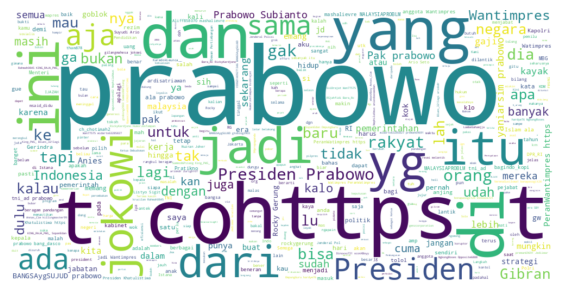

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Menggunakan 'tweet_text' karena kolom 'text' tidak ada di DataFrame
text = ' '.join(df['tweet_text'].dropna().astype(str))

wordcloud = WordCloud(width=1000, height=500, background_color='white', max_words=500).generate(text)

plt.figure(figsize=(7, 4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

**4.2 Analisis Frekuensi Kata Utama (Top 20 Kata Terbanyak)**

Menghitung dan memvisualisasikan 20 kata yang paling sering muncul menggunakan diagram batang (*bar chart*).

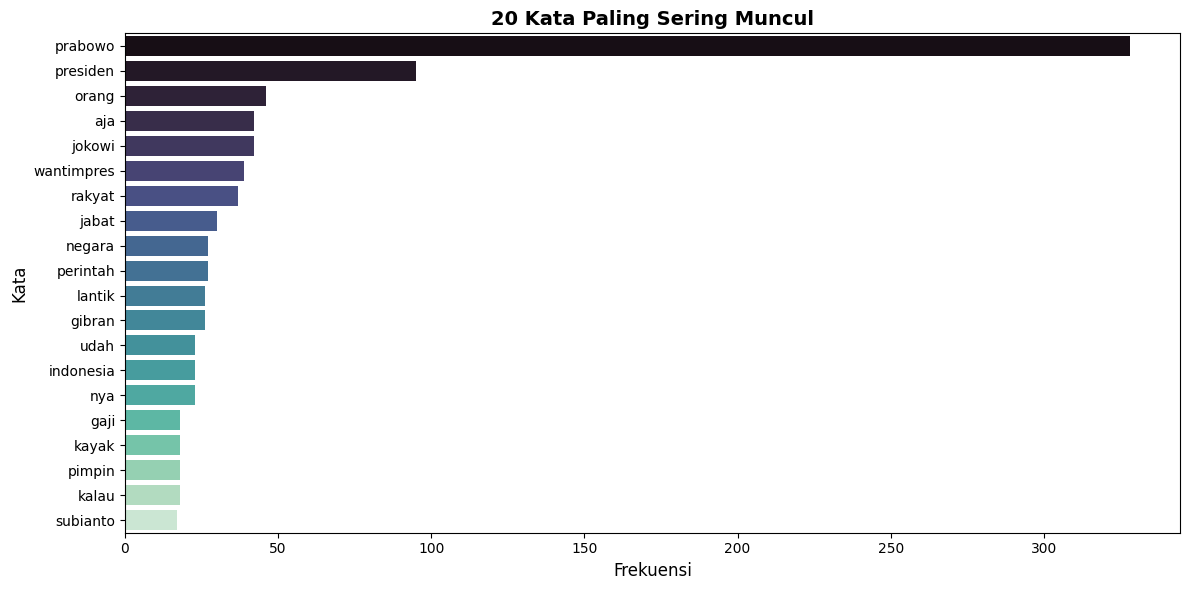

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Mengumpulkan seluruh token dari kolom final_tokens
all_tokens = [token for tokens in df['final_tokens'].dropna() for token in tokens]
word_counts = Counter(all_tokens)

# Mengambil 20 kata teratas
top_20 = word_counts.most_common(20)
top_words, counts = zip(*top_20)

# Visualisasi Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(x=list(counts), y=list(top_words), palette='mako')
plt.title('20 Kata Paling Sering Muncul', fontsize=14, fontweight='bold')
plt.xlabel('Frekuensi', fontsize=12)
plt.ylabel('Kata', fontsize=12)
plt.tight_layout()
plt.show()

**4.3 Analisis Frekuensi N-Gram (Bigram & Trigram)**

Menganalisis kemunculan kombinasi 2 kata (*Bigram*) dan 3 kata (*Trigram*) secara berurutan untuk memahami frasa kunci dan konteks percakapan.

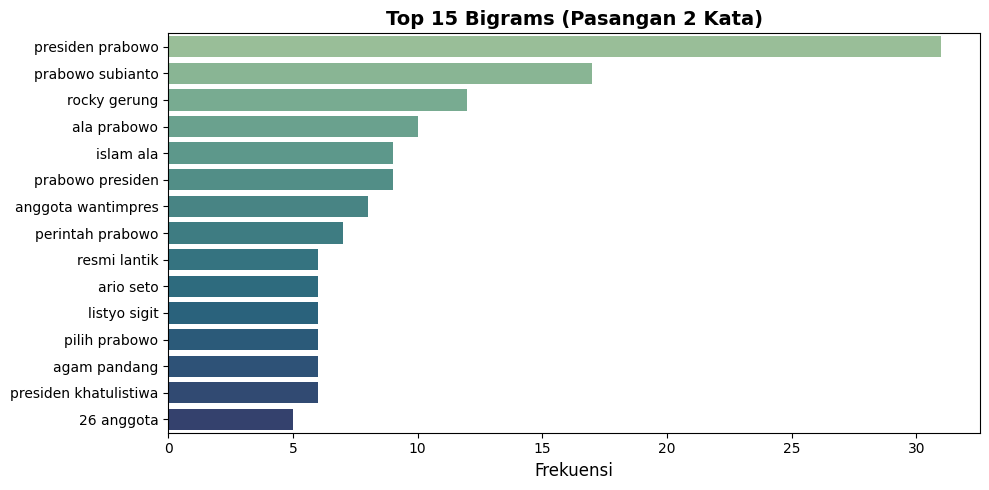

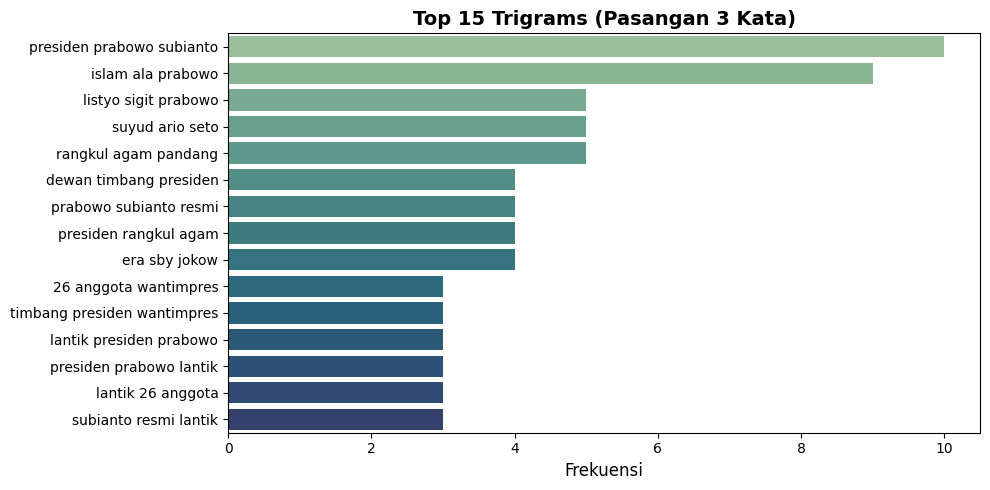

In [70]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

def plot_ngrams(text_series, n=2, top_k=15, title='Top N-Grams'):
    vec = CountVectorizer(ngram_range=(n, n)).fit(text_series)
    bag_of_words = vec.transform(text_series)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_k]

    words, counts = zip(*words_freq)

    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(counts), y=list(words), palette='crest')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Frekuensi', fontsize=12)
    plt.tight_layout()
    plt.show()

# Visualisasi Top 15 Bigrams (2 Kata Berurutan)
plot_ngrams(df['final_text'].dropna(), n=2, top_k=15, title='Top 15 Bigrams (Pasangan 2 Kata)')

# Visualisasi Top 15 Trigrams (3 Kata Berurutan)
plot_ngrams(df['final_text'].dropna(), n=3, top_k=15, title='Top 15 Trigrams (Pasangan 3 Kata)')

**4.4 Visualisasi Distribusi Panjang Tweet (Kata & Karakter)**

Menghitung statistik dan sebaran panjang tweet berdasarkan jumlah kata dan karakter setelah proses *preprocessing*.

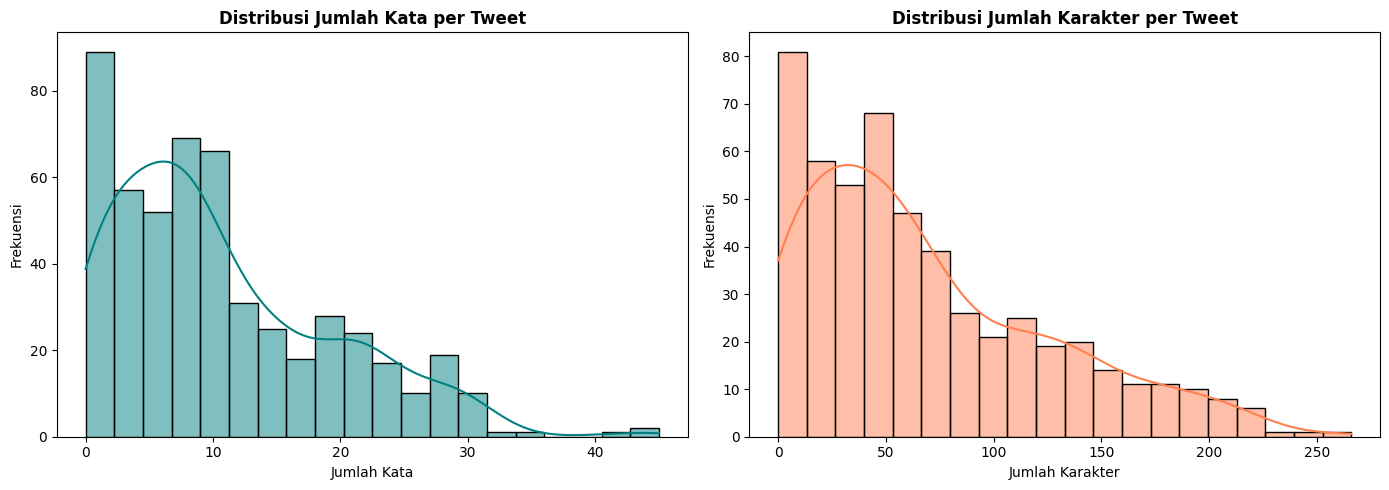

       STATISTIK DESKRIPTIF PANJANG TWEET       
       word_count  char_count
count  520.000000  520.000000
mean    10.615385   68.863462
std      8.657370   57.493927
min      0.000000    0.000000
25%      4.000000   24.750000
50%      8.000000   53.500000
75%     16.000000  106.000000
max     45.000000  266.000000


In [71]:
import pandas as pd

# Menghitung jumlah karakter dan jumlah kata pada final_text
df['char_count'] = df['final_text'].apply(lambda x: len(str(x)))
df['word_count'] = df['final_text'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram Distribusi Jumlah Kata
sns.histplot(df['word_count'], kde=True, ax=axes[0], color='teal', bins=20)
axes[0].set_title('Distribusi Jumlah Kata per Tweet', fontweight='bold')
axes[0].set_xlabel('Jumlah Kata')
axes[0].set_ylabel('Frekuensi')

# Histogram Distribusi Jumlah Karakter
sns.histplot(df['char_count'], kde=True, ax=axes[1], color='coral', bins=20)
axes[1].set_title('Distribusi Jumlah Karakter per Tweet', fontweight='bold')
axes[1].set_xlabel('Jumlah Karakter')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

# Menampilkan ringkasan statistik deskriptif
print("="*50)
print("       STATISTIK DESKRIPTIF PANJANG TWEET       ")
print("="*50)
print(df[['word_count', 'char_count']].describe())

**4.5 Visualisasi Tren Waktu Tweet**

Menganalisis tren postingan tweet berdasarkan waktu (jam atau tanggal) menggunakan kolom `created_at`.

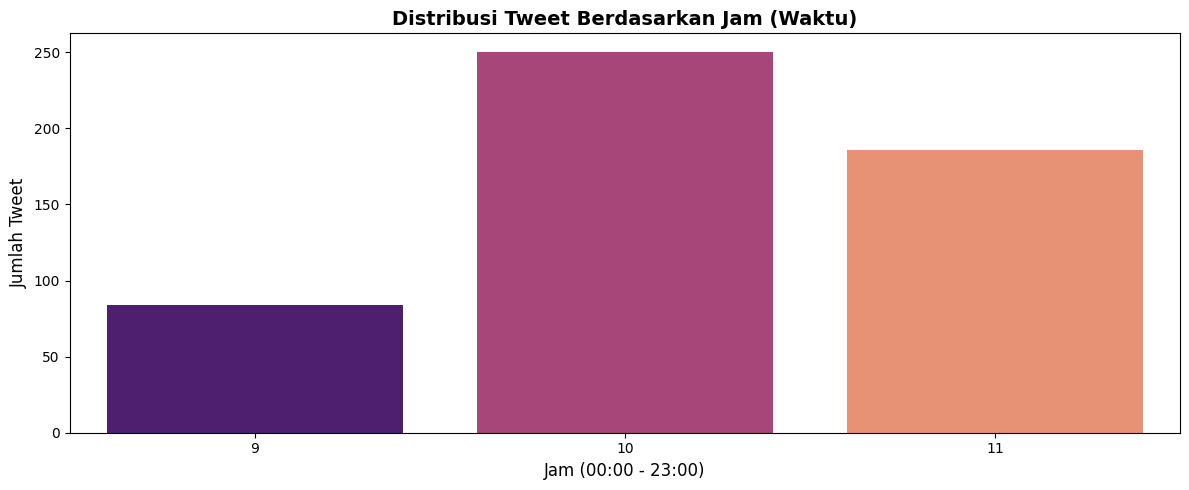

In [72]:
if 'created_at' in df.columns:
    df['datetime'] = pd.to_datetime(df['created_at'], errors='coerce')
    df['hour'] = df['datetime'].dt.hour
    df['date'] = df['datetime'].dt.date

    plt.figure(figsize=(12, 5))

    # Jika data mencakup lebih dari 1 hari, tampilkan tren harian
    if df['date'].nunique() > 1:
        tweet_by_date = df.groupby('date').size()
        plt.plot(tweet_by_date.index, tweet_by_date.values, marker='o', color='royalblue', linewidth=2)
        plt.title('Tren Volume Tweet dari Waktu ke Waktu', fontsize=14, fontweight='bold')
        plt.xlabel('Tanggal', fontsize=12)
        plt.ylabel('Jumlah Tweet', fontsize=12)
        plt.xticks(rotation=45)
    else:
        # Jika data berasal dari 1 hari yang sama, tampilkan distribusi per jam
        sns.countplot(data=df, x='hour', palette='magma')
        plt.title('Distribusi Tweet Berdasarkan Jam (Waktu)', fontsize=14, fontweight='bold')
        plt.xlabel('Jam (00:00 - 23:00)', fontsize=12)
        plt.ylabel('Jumlah Tweet', fontsize=12)

    plt.tight_layout()
    plt.show()
else:
    print("Kolom 'created_at' tidak ditemukan dalam dataframe.")